# 최종 학습 데이터 후보 939개에 대한 voxel spacing 분석

In [1]:
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_ROOT = Path(r"C:\Users\comds\Desktop\졸업작품\dataset\CTSpine1K\raw_data")
VOLUME_ROOT = DATA_ROOT / "volumes"
LABEL_ROOT = DATA_ROOT / "labels"

SOURCES = ["COLONOG", "COVID-19", "MSD-T10"]

In [2]:
df_t11_t12_final = pd.read_pickle("df_t11_t12_final_candidates.pkl")

## spacing 추출

In [3]:
spacing_rows = []

for idx, row in enumerate(df_t11_t12_final.itertuples(index=False), start=1):
    volume_path = VOLUME_ROOT / row.source / row.file_name

    img = nib.load(volume_path)

    shape = img.shape[:3]
    spacing = img.header.get_zooms()[:3]

    spacing_rows.append({
        "source": row.source,
        "patient_id": row.patient_id,
        "file_name": row.file_name,
        "shape_x": shape[0],
        "shape_y": shape[1],
        "shape_z": shape[2],
        "spacing_x": spacing[0],
        "spacing_y": spacing[1],
        "spacing_z": spacing[2],
    })

    if idx % 100 == 0:
        print(f"Processed {idx}/{len(df_t11_t12_final)}")

df_spacing_final = pd.DataFrame(spacing_rows)

display(df_spacing_final.head())

Processed 100/939
Processed 200/939
Processed 300/939
Processed 400/939
Processed 500/939
Processed 600/939
Processed 700/939
Processed 800/939
Processed 900/939


,source,patient_id,file_name,shape_x,shape_y,shape_z,spacing_x,spacing_y,spacing_z
0,COLONOG,1.3.6.1.4.1.9328.50.4.0001,1.3.6.1.4.1.9328.50.4.0001.nii.gz,512,512,604,0.781250,0.781250,0.8
1,COLONOG,1.3.6.1.4.1.9328.50.4.0002,1.3.6.1.4.1.9328.50.4.0002.nii.gz,512,512,637,0.781250,0.781250,0.8
2,COLONOG,1.3.6.1.4.1.9328.50.4.0003,1.3.6.1.4.1.9328.50.4.0003.nii.gz,512,512,663,0.781250,0.781250,0.8
3,COLONOG,1.3.6.1.4.1.9328.50.4.0004,1.3.6.1.4.1.9328.50.4.0004.nii.gz,512,512,520,0.781250,0.781250,0.8
4,COLONOG,1.3.6.1.4.1.9328.50.4.0005,1.3.6.1.4.1.9328.50.4.0005.nii.gz,512,512,401,0.605469,0.605469,1.0


## source별 spacing통계

#### spacing vs shape vs physical size
- spacing : voxel하나가 실제 몸에서 차지하는 크기(mm단위) 즉 spacing_x = 0.7 mm이면 x 방향 voxel의 간격은 0.7mm라는 뜻
- shape : (512, 512, 500) -> voxel의 개수
- physical size : 전체 CT volume의 실제 길이
- 따라서 shape가 클수록 spacing은 작아짐
- spacing의 크기가 작을수록 해상도가 높아짐

### x,y,z방향

- spacing_x = 0.7 mm, shape_x = 512라면
 - x 방향 실제 촬영 폭 = 512 * 0.7 = 약 358 mm -> 몸통 가로 폭이 35.8cm
- x방향 : coronal방향에서 가로방향
- y방향 : coronal방향에서 세로방향
- z방향 : 몸의 위아래 방향 , slice개수는 z방향의 크기


In [5]:
display(
    df_spacing_final
    .groupby("source")[["spacing_x", "spacing_y", "spacing_z"]]
    .describe()
)

spacing_x                                                    \
             count      mean       std       min       25%       50%   
source                                                                 
COLONOG      752.0  0.747327  0.079175  0.527344  0.695312  0.761719   
COVID-19      37.0  0.789892  0.097200  0.449000  0.741000  0.741000   
MSD-T10      150.0  0.766247  0.103308  0.556641  0.691894  0.748047   

                             spacing_y            ...                      \
               75%       max     count      mean  ...       75%       max   
source                                            ...                       
COLONOG   0.781250  0.976562     752.0  0.747327  ...  0.781250  0.976562   
COVID-19  0.854000  1.049000      37.0  0.789892  ...  0.854000  1.049000   
MSD-T10   0.819336  1.000000     150.0  0.766247  ...  0.819336  1.000000   

         spacing_z                                                    
             count      mean       std       min  25%  50%  75%  max  
source                                                                
COLONOG      752.0  0.812468  0.158325  0.625000  0.8  0.8  0.8  5.0  
COVID-19      37.0  4.562162  1.275268  0.799988  5.0  5.0  5.0  5.0  
MSD-T10      150.0  1.547332  1.219154  0.450000  0.8  1.0  2.0  5.0  

[3 rows x 24 columns]

- spacing_z에서만 차이가 있음
 - colonog : 0.812468
 - covid : 4.562162
 - msd : 1.547332

In [6]:
display(
    df_spacing_final
    .groupby("source")["spacing_z"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
COLONOG,752.0,0.812468,0.158325,0.625000,0.8,0.8,0.8,5.0
COVID-19,37.0,4.562162,1.275268,0.799988,5.0,5.0,5.0,5.0
MSD-T10,150.0,1.547332,1.219154,0.450000,0.8,1.0,2.0,5.0


### source별 spacing(mm) 크기 - boxplot

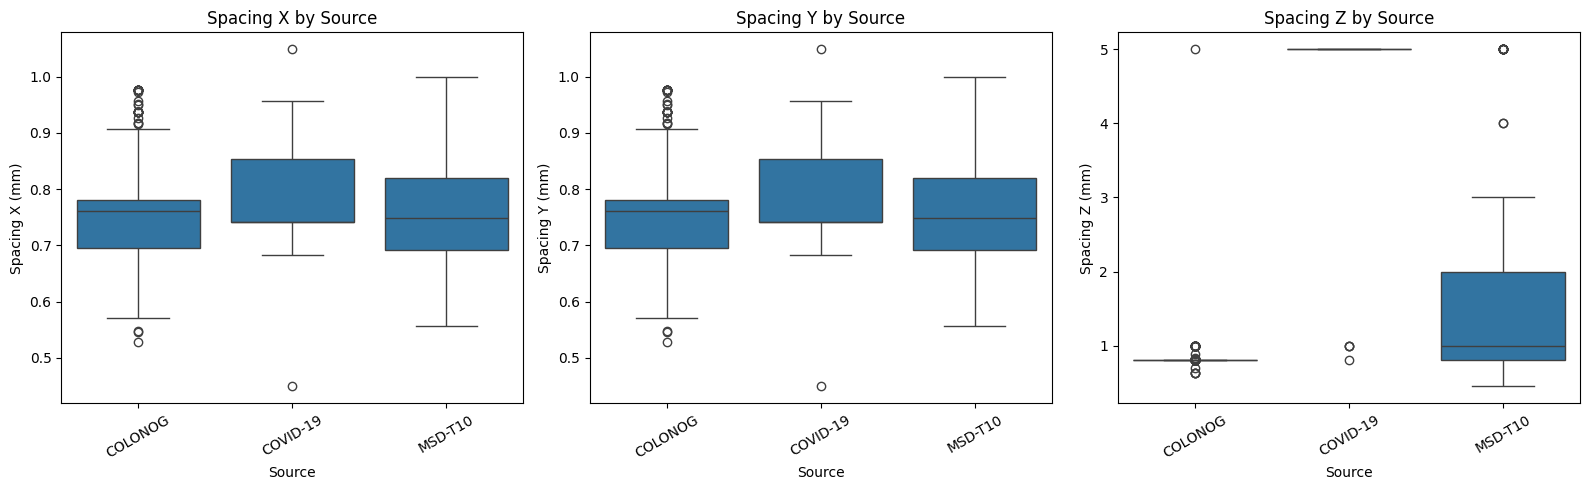

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(
    data=df_spacing_final,
    x="source",
    y="spacing_x",
    order=SOURCES,
    ax=axes[0],
)
axes[0].set_title("Spacing X by Source")
axes[0].set_ylabel("Spacing X (mm)")

sns.boxplot(
    data=df_spacing_final,
    x="source",
    y="spacing_y",
    order=SOURCES,
    ax=axes[1],
)
axes[1].set_title("Spacing Y by Source")
axes[1].set_ylabel("Spacing Y (mm)")

sns.boxplot(
    data=df_spacing_final,
    x="source",
    y="spacing_z",
    order=SOURCES,
    ax=axes[2],
)
axes[2].set_title("Spacing Z by Source")
axes[2].set_ylabel("Spacing Z (mm)")

for ax in axes:
    ax.set_xlabel("Source")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Physical size 계산
- shape은 voxel 개수이고 spacing은 voxel 하나의 실제 크기
- 둘을 곱하면 실제 촬영 범위(mm)가 됨

In [9]:
df_spacing_final["physical_x_mm"] = (
    df_spacing_final["shape_x"] * df_spacing_final["spacing_x"]
)
df_spacing_final["physical_y_mm"] = (
    df_spacing_final["shape_y"] * df_spacing_final["spacing_y"]
)
df_spacing_final["physical_z_mm"] = (
    df_spacing_final["shape_z"] * df_spacing_final["spacing_z"]
)

display(
    df_spacing_final
    .groupby("source")[["physical_x_mm", "physical_y_mm", "physical_z_mm"]]
    .describe()
)

physical_x_mm                                              \
                 count        mean        std      min         25%   
source                                                               
COLONOG          752.0  382.631618  40.537600  270.000  356.000000   
COVID-19          37.0  404.424649  49.766644  229.888  379.391998   
MSD-T10          150.0  392.318563  52.893488  285.000  354.249908   

                                             physical_y_mm              ...  \
                 50%         75%         max         count        mean  ...   
source                                                                  ...   
COLONOG   390.000061  400.000000  500.000000         752.0  382.631618  ...   
COVID-19  379.391998  437.247986  537.088013          37.0  404.424649  ...   
MSD-T10   383.000000  419.500000  512.000000         150.0  392.318563  ...   

                                 physical_z_mm                          \
                 75%         max         count        mean         std   
source                                                                   
COLONOG   400.000000  500.000000         752.0  439.986781   37.635788   
COVID-19  437.247986  537.088013          37.0  321.605337   38.482098   
MSD-T10   419.500000  512.000000         150.0  508.816119  140.557084   

                                                                      
                 min         25%         50%         75%         max  
source                                                                
COLONOG   358.399979  411.799983  437.600007  465.801042  572.800009  
COVID-19  166.397461  305.000000  330.000000  350.000000  365.000000  
MSD-T10    91.000000  434.699998  496.250000  626.450002  716.800011  

[3 rows x 24 columns]

### source별 physical z length - boxplot

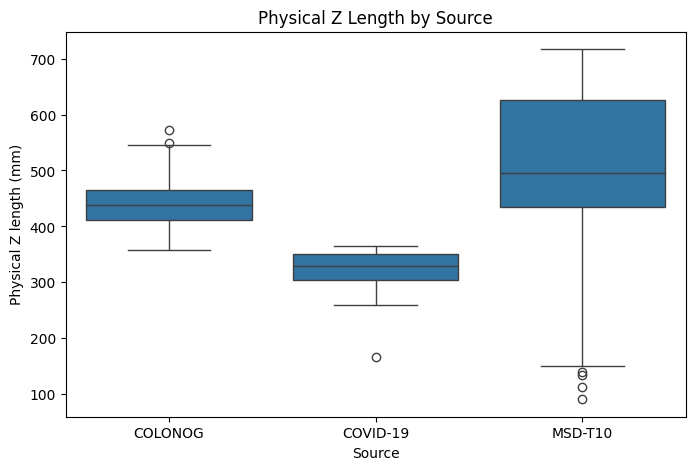

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_spacing_final,
    x="source",
    y="physical_z_mm",
    order=SOURCES,
)

plt.title("Physical Z Length by Source")
plt.xlabel("Source")
plt.ylabel("Physical Z length (mm)")
plt.show()

### slice count, spacing_z 확인 - scatterplot

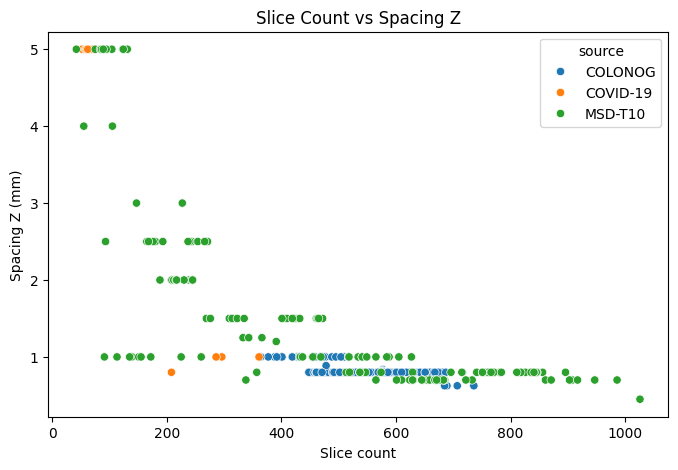

In [11]:
df_spacing_final["slice_count"] = df_spacing_final["shape_z"]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_spacing_final,
    x="slice_count",
    y="spacing_z",
    hue="source",
)

plt.title("Slice Count vs Spacing Z")
plt.xlabel("Slice count")
plt.ylabel("Spacing Z (mm)")
plt.show()

In [12]:
display(
    df_spacing_final[["spacing_x", "spacing_y", "spacing_z"]]
    .quantile([0.1, 0.25, 0.5, 0.75, 0.9])
)

,spacing_x,spacing_y,spacing_z
0.10,0.648438,0.648438,0.80
0.25,0.699219,0.699219,0.80
0.50,0.756000,0.756000,0.80
0.75,0.781250,0.781250,0.80
0.90,0.859375,0.859375,1.25


### source별 median값

In [13]:
display(
    df_spacing_final
    .groupby("source")[["spacing_x", "spacing_y", "spacing_z"]]
    .median()
)

,spacing_x,spacing_y,spacing_z
source,,,
COLONOG,0.761719,0.761719,0.8
COVID-19,0.741000,0.741000,5.0
MSD-T10,0.748047,0.748047,1.0


### 결과 저장

In [14]:
df_spacing_final.to_pickle("df_spacing_final.pkl")

df_spacing_final.to_csv(
    "df_spacing_final.csv",
    index=False,
    encoding="utf-8-sig",
)

1. spacing_x, spacing_y는 source별로 비슷한가?
2. spacing_z가 source별로 크게 다른가?
3. COVID의 bbox_z_size가 작았던 이유가 spacing_z가 크기 때문인가?
4. physical_z_mm는 COVID도 충분히 긴가, 아니면 실제 촬영 범위도 짧은가?
5. resampling target spacing을 1.0 x 1.0 x 1.0으로 할지, 1.0 x 1.0 x 2.0으로 할지

- 해상도는 x, y, z spacing 모두와 관련 있음.
- slice 개수는 주로 z 방향 개수.
- x/y 해상도는 spacing_x, spacing_y로 판단.
- z 해상도는 spacing_z로 판단.

## spacing_z resampling

resampling : (1.0, 1.0, 2.0)

- covid의 z 방향 slice 간격을 2.0mm 기준으로 다시 샘플링
- 나머지 source는 1.0으로 샘플링
- slice 수는 증가
- 하지만 실제 해상도가 진짜 좋아지는 건 아니고 보간된 slice가 생김